# Simulation Method Validation and PSS Window Sticker

This notebook is analysis-only. Run `examples/IBM_QAOA/run_job.sh` or `examples/IBM_QAOA/run_job_small.sh` first to generate the IBM QAOA campaign artifacts, then load and analyze them here.


In [275]:
# Analysis imports
import importlib
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from src.utils import (
    apply_shared_approx_axis,
    concat_summary,
    cross_strategy_envelope,
    curve_from_training_summary,
    curve_from_window_summary,
    curve_label,
    load_multi_strategy_summaries,
    plot_exact_resource_model_predictions,
    plot_method_curves,
    plot_multi_method_window_sticker_components,
    plot_parameter_prescriptions_by_resource,
    prepare_monotone_curve,
    save_current_plot,
    shared_approx_ylim as compute_shared_approx_ylim,
    shared_approx_yticks as compute_shared_approx_yticks,
    window_sticker_curve_colors,
    window_sticker_method_color,
)
from src.simulation_validation import (
    build_resource_frontier_from_exact_points,
    build_binned_budget_dataset,
    build_strategy_budget_summary,
    estimate_hardware_time_per_shot,
    fit_exact_resource_models,
    run_stochastic_benchmark_pss,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams.update({
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.titlesize': 16,
    'figure.titlesize': 16,
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [276]:
# Analysis configuration
GRAPH_TYPE = 'heavy_hex'
NUM_NODES = 144
REPO_ROOT = Path('../../..').resolve()
WORKSPACE_ROOT = REPO_ROOT.parent
QAOA_PARAMETER_SETTING_ROOT = Path(
    os.environ.get('QAOA_PARAMETER_SETTING_ROOT', WORKSPACE_ROOT / 'QAOA-Parameter-Setting')
).expanduser().resolve()
HARDWARE_RESULTS_ROOT = QAOA_PARAMETER_SETTING_ROOT / 'data' / 'hardware'

from src import simulation_validation as ibm_qaoa_sim_validation
ibm_qaoa_sim_validation = importlib.reload(ibm_qaoa_sim_validation)
estimate_hardware_time_per_shot = ibm_qaoa_sim_validation.estimate_hardware_time_per_shot
RESULT_TAG = 'heavy_hex_144_FA_no_opt_p5_expanded'
RESULT_JOB_P_MATCH = re.search(r'_p(\d+)', RESULT_TAG)
RESULT_JOB_P = int(RESULT_JOB_P_MATCH.group(1)) if RESULT_JOB_P_MATCH else None
INCLUDE_PT_TRANSFER_COST = True
PT_TRANSFER_COST_SECONDS = None  # None uses measured transfer lookup time from PT raw rows.
SHOW_WINDOW_STICKER_CI = False
SKIP_MISSING_MULTI_STRATEGY_SUMMARIES = True

TIME_PER_SHOT = estimate_hardware_time_per_shot(
    HARDWARE_RESULTS_ROOT,
    graph_type=GRAPH_TYPE,
    num_nodes=NUM_NODES,
    job_p=RESULT_JOB_P,
    statistic='median',
    normalize_by_pubs=True,
)
COMPARISON_RESULT_TAGS = [
    'heavy_hex_144_FA_PP_opt_p5_expanded',
    'heavy_hex_144_LR_opt_p5_expanded',
    'heavy_hex_144_PT_p7_expanded',
    'heavy_hex_144_PT_p6_expanded',
    'heavy_hex_144_PT_p5_expanded',
    'heavy_hex_144_PT_p3_expanded',
    'heavy_hex_144_PT_p2_expanded',
    'heavy_hex_144_FA_no_opt_p2_expanded',
    'heavy_hex_144_FA_no_opt_p3_expanded',
    'heavy_hex_144_FA_no_opt_p4_expanded',
    'heavy_hex_144_FA_no_opt_p5_expanded',
]

BS_BOOTSTRAP_RANGE = range(10, 51, 10)
TRAIN_TEST_SPLIT_FRACTION = 0.5

OUTPUT_ROOT = Path(f'../results/pss_window_sticker/{RESULT_TAG}').resolve()
WINDOW_STICKER_DIR = OUTPUT_ROOT / 'window_sticker'
EXACT_RESOURCE_ROOT = OUTPUT_ROOT / 'exact_resource'
EXACT_WINDOW_STICKER_DIR = EXACT_RESOURCE_ROOT / 'window_sticker'
PLOT_DIR = OUTPUT_ROOT / 'notebook_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FRONTIER_PATH = OUTPUT_ROOT / 'pss_exp_raw_frontier.pkl'
STRATEGY_EXACT_PATH = OUTPUT_ROOT / 'strategy_raw_points.pkl'
LEGACY_FA_EXACT_PATH = OUTPUT_ROOT / 'fa_raw_points.pkl'
TRANSFER_EXACT_PATH = OUTPUT_ROOT / 'transfer_raw_points.pkl'
LEGACY_PT_EXACT_PATH = OUTPUT_ROOT / 'pt_raw_points.pkl'
TRAIN_SPECS_PATH = OUTPUT_ROOT / 'train_instance_specs.csv'
TEST_SPECS_PATH = OUTPUT_ROOT / 'test_instance_specs.csv'
CODEBOOK_PATH = OUTPUT_ROOT / 'ws_codebooks.json'
FRONTIER_PREVIEW_PATH = OUTPUT_ROOT / 'frontier_preview.csv'
FRONTIER_SUMMARY_PATH = OUTPUT_ROOT / 'frontier_group_summary.csv'


In [277]:
# Load campaign artifacts generated by the terminal script
raw_exact_paths = []
for primary_path, legacy_path in [
    (STRATEGY_EXACT_PATH, LEGACY_FA_EXACT_PATH),
    (TRANSFER_EXACT_PATH, LEGACY_PT_EXACT_PATH),
]:
    raw_path = primary_path if primary_path.exists() else legacy_path
    if raw_path.exists() and raw_path not in raw_exact_paths:
        raw_exact_paths.append(raw_path)

missing_paths = [path for path in [CODEBOOK_PATH] if not path.exists()]
if not raw_exact_paths:
    missing_paths.append(f'{STRATEGY_EXACT_PATH} or {TRANSFER_EXACT_PATH}')
if missing_paths:
    missing = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'Missing campaign artifacts. Run examples/IBM_QAOA/run_job.sh or '
        'examples/IBM_QAOA/run_job_small.sh first:\n' + missing
    )

exact_frames = [pd.read_pickle(path) for path in raw_exact_paths]
exact_df = pd.concat(exact_frames, ignore_index=True)
ws_codebooks = json.loads(CODEBOOK_PATH.read_text(encoding='utf-8'))

for col in ['N', 'M', 'Q']:
    if col not in exact_df.columns:
        exact_df[col] = 0
    exact_df[col] = pd.to_numeric(exact_df[col], errors='coerce').fillna(0.0)

if 'p' in exact_df.columns:
    exact_p_values = sorted(
        pd.to_numeric(exact_df['p'], errors='coerce').dropna().round().astype(int).unique().tolist()
    )
else:
    exact_p_values = [RESULT_JOB_P] if RESULT_JOB_P is not None else []
TIME_PER_SHOT_BY_P = {}
for p_value in exact_p_values:
    try:
        TIME_PER_SHOT_BY_P[int(p_value)] = estimate_hardware_time_per_shot(
            HARDWARE_RESULTS_ROOT,
            graph_type=GRAPH_TYPE,
            num_nodes=NUM_NODES,
            job_p=int(p_value),
            statistic='median',
            normalize_by_pubs=True,
        )
    except (FileNotFoundError, ValueError):
        TIME_PER_SHOT_BY_P[int(p_value)] = TIME_PER_SHOT

if 'p' in exact_df.columns and TIME_PER_SHOT_BY_P:
    p_for_proxy = pd.to_numeric(exact_df['p'], errors='coerce').round().astype('Int64')
    exact_df['_hardware_time_per_shot'] = p_for_proxy.map(TIME_PER_SHOT_BY_P).astype(float)
    exact_df['_hardware_time_per_shot'] = exact_df['_hardware_time_per_shot'].fillna(TIME_PER_SHOT)
else:
    exact_df['_hardware_time_per_shot'] = TIME_PER_SHOT

training_shot_cost_proxy = exact_df['N'] * exact_df['M'] * exact_df['_hardware_time_per_shot']
transfer_strategy_mask = pd.Series(False, index=exact_df.index)
for transfer_col in ['strategy', 'strategy_family', 'method_label', 'strategy_runtime_label']:
    if transfer_col in exact_df.columns:
        transfer_strategy_mask |= exact_df[transfer_col].astype(str).str.contains(
            r'PT|Param\.? Transfer|Parameter Transfer|transfer',
            case=False,
            regex=True,
            na=False,
        )
transfer_strategy_mask |= (exact_df['N'].eq(0) & exact_df['M'].eq(0))

pt_transfer_cost_proxy = pd.Series(0.0, index=exact_df.index)
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    if PT_TRANSFER_COST_SECONDS is None:
        if 'runtime_train_wallclock' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['runtime_train_wallclock'], errors='coerce').fillna(0.0)
        elif 'classical_setup_cost' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['classical_setup_cost'], errors='coerce').fillna(0.0)
        else:
            measured_transfer = pd.Series(0.0, index=exact_df.index)
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = measured_transfer.loc[transfer_strategy_mask]
    else:
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = float(PT_TRANSFER_COST_SECONDS)

exact_df['classical_setup_cost_proxy'] = pt_transfer_cost_proxy
exact_df['training_cost_proxy'] = training_shot_cost_proxy + pt_transfer_cost_proxy
exact_df['sampling_cost_proxy'] = exact_df['Q'] * exact_df['_hardware_time_per_shot']
exact_df['T_proxy'] = exact_df['training_cost_proxy'] + exact_df['sampling_cost_proxy']
exact_df['T_exact_proxy'] = exact_df['T_proxy']

stored_frontier_df = pd.read_pickle(FRONTIER_PATH) if FRONTIER_PATH.exists() else pd.DataFrame()
budget_grid_points = int(stored_frontier_df['T'].nunique()) if not stored_frontier_df.empty else 1000

frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_proxy',
    scale='log',
)

exact_frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_exact',
    scale='log',
)

train_specs_df = pd.read_csv(TRAIN_SPECS_PATH) if TRAIN_SPECS_PATH.exists() else pd.DataFrame()
test_specs_df = pd.read_csv(TEST_SPECS_PATH) if TEST_SPECS_PATH.exists() else pd.DataFrame()
frontier_preview_df = frontier_df.head(30).copy()
frontier_summary_df = frontier_df.groupby(['split', 'strategy'], as_index=False).agg(
    n_rows=('instance', 'size'),
    min_T=('T', 'min'),
    max_T=('T', 'max'),
    best_response=('BestApproximationRatio', 'max'),
)

print('Loaded campaign from:', OUTPUT_ROOT)
print(f'Hardware-derived TIME_PER_SHOT: {TIME_PER_SHOT:.12g} s from {HARDWARE_RESULTS_ROOT} (job_p={RESULT_JOB_P})')
print('Hardware-derived TIME_PER_SHOT_BY_P:', TIME_PER_SHOT_BY_P or {'default': TIME_PER_SHOT})
print('Raw exact artifacts:', [path.name for path in raw_exact_paths])
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    pt_transfer_values = pt_transfer_cost_proxy.loc[transfer_strategy_mask]
    print(
        'PT transfer preprocessing cost in proxy: '
        f'median={pt_transfer_values.median():.6g} s, '
        f'min={pt_transfer_values.min():.6g} s, '
        f'max={pt_transfer_values.max():.6g} s'
    )
print('Exact rows:', len(exact_df))
print('Clean proxy binned frontier rows:', len(frontier_df))
print('Clean proxy budget bins used:', frontier_df['T'].nunique())
print('Exact binned frontier rows:', len(exact_frontier_df))
print('Exact budget bins used:', exact_frontier_df['T'].nunique())
print('Strategies:', sorted(frontier_df['strategy'].dropna().unique()))
print('Splits:', sorted(frontier_df['split'].dropna().unique()))


Loaded campaign from: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded
Hardware-derived TIME_PER_SHOT: 0.000280309606481 s from /mnt/c/Users/rames102/Desktop/QAOA-Parameter-Setting/data/hardware (job_p=5)
Hardware-derived TIME_PER_SHOT_BY_P: {5: 0.0002803096064814815}
Raw exact artifacts: ['transfer_raw_points.pkl']
PT transfer preprocessing cost in proxy: median=2.21729e-05 s, min=1.04904e-05 s, max=0.000114441 s
Exact rows: 3000
Clean proxy binned frontier rows: 3000
Clean proxy budget bins used: 100
Exact binned frontier rows: 3000
Exact budget bins used: 100
Strategies: ['FA_PP_no_opt']
Splits: ['test', 'train']


In [278]:
# Quick artifact preview
display(train_specs_df.head(10))
display(test_specs_df.head(10))
display(frontier_preview_df)
display(frontier_summary_df)


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,100,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
1,heavy_hex,144,101,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
2,heavy_hex,144,102,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
3,heavy_hex,144,103,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
4,heavy_hex,144,104,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
5,heavy_hex,144,105,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
6,heavy_hex,144,106,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
7,heavy_hex,144,107,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
8,heavy_hex,144,108,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
9,heavy_hex,144,109,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,0,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
1,heavy_hex,144,1,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
2,heavy_hex,144,2,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
3,heavy_hex,144,3,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
4,heavy_hex,144,4,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
5,heavy_hex,144,5,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
6,heavy_hex,144,6,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
7,heavy_hex,144,7,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
8,heavy_hex,144,8,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
9,heavy_hex,144,9,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test


,graph_type,num_nodes,instance,instance_id,split,source,p,strategy,strategy_family,strategy_runtime_label,simulation_method,N,M,classical_setup_cost,training_cost,sampling_cost,T_exact,classical_setup_cost_proxy,training_cost_proxy,sampling_cost_proxy,T_exact_proxy,runtime_train_wallclock,runtime_sample_wallclock,Q,counts,best_bitstring,best_found_value,BestApproximationRatio,Approximation_Ratio,num_objective_evaluations,total_training_shots,_hardware_time_per_shot,T_proxy,budget_bin,budget_left,budget_right,T,resource,selected_exact_T,selected_exact_T_proxy,budget_distance,strategy_code,simulation_code,train
0,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.099200,0.099315,0.000114,0.000114,0.028031,0.028145,0.000114,0.099200,100,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.028145,0,0.028041,0.030047,0.029027,0.029027,0.099315,0.028145,0.0,0.0,0.0,1
1,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.106144,0.106259,0.000114,0.000114,0.029993,0.030108,0.000114,0.106144,107,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.030108,1,0.030047,0.032196,0.031103,0.031103,0.106259,0.030108,0.0,0.0,0.0,1
2,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.114080,0.114195,0.000114,0.000114,0.032236,0.032350,0.000114,0.114080,115,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.032350,2,0.032196,0.034498,0.033327,0.033327,0.114195,0.032350,0.0,0.0,0.0,1
3,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.122016,0.122131,0.000114,0.000114,0.034478,0.034593,0.000114,0.122016,123,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.034593,3,0.034498,0.036965,0.035710,0.035710,0.122131,0.034593,0.0,0.0,0.0,1
4,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.130945,0.131059,0.000114,0.000114,0.037001,0.037115,0.000114,0.130945,132,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.037115,4,0.036965,0.039609,0.038264,0.038264,0.131059,0.037115,0.0,0.0,0.0,1
5,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.140865,0.140979,0.000114,0.000114,0.039804,0.039918,0.000114,0.140865,142,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.039918,5,0.039609,0.042442,0.041001,0.041001,0.140979,0.039918,0.0,0.0,0.0,1
6,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.150785,0.150899,0.000114,0.000114,0.042607,0.042722,0.000114,0.150785,152,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.042722,6,0.042442,0.045477,0.043933,0.043933,0.150899,0.042722,0.0,0.0,0.0,1
7,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.161697,0.161811,0.000114,0.000114,0.045690,0.045805,0.000114,0.161697,163,{'00011111111011111110011100011110110011100010...,0011100001110001111001110011010000001111110110...,50.713674,0.848876,0.848876,0,0,0.00028,0.045805,7,0.045477,0.048729,0.047075,0.047075,0.161811,0.045805,0.0,0.0,0.0,1
8,heavy_hex,144,100,100,train,generated_train,5,FA_PP_no_opt,FA,FA_PP_no_opt_5,MPSAer,0,0,0.000114,0.000114,0.173601,0.173715,0.000114,0.000114,0.049054,0.0491

,split,strategy,n_rows,min_T,max_T,best_response
0,test,FA_PP_no_opt,1000,0.029027,27.079495,0.902666
1,train,FA_PP_no_opt,2000,0.029027,27.079495,0.917831


In [279]:
# Inspect the available encoded metadata before running stochastic-benchmark
display(pd.DataFrame({
    'strategy_code': list(ws_codebooks.get('strategy', {}).keys()),
    'strategy_name': list(ws_codebooks.get('strategy', {}).values()),
}))
display(pd.DataFrame({
    'simulation_code': list(ws_codebooks.get('simulation', {}).keys()),
    'simulation_name': list(ws_codebooks.get('simulation', {}).values()),
}))


,strategy_code,strategy_name
0,0,FA_PP_no_opt


,simulation_code,simulation_name
0,0,MPSAer


,model,expression,alpha,beta,power_slope
0,through_origin,T_exact ≈ 3.67326 · T_proxy,3.673261,0.00000,1.000000
1,affine,T_exact ≈ 3.67327 · T_proxy + -6.9705e-05,3.673266,-0.00007,1.000000
2,power_law,T_exact ≈ 3.67011 · T_proxy^1.00006,3.670106,0.00000,1.000062


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/proxy_vs_exact_calibration.pdf and .png


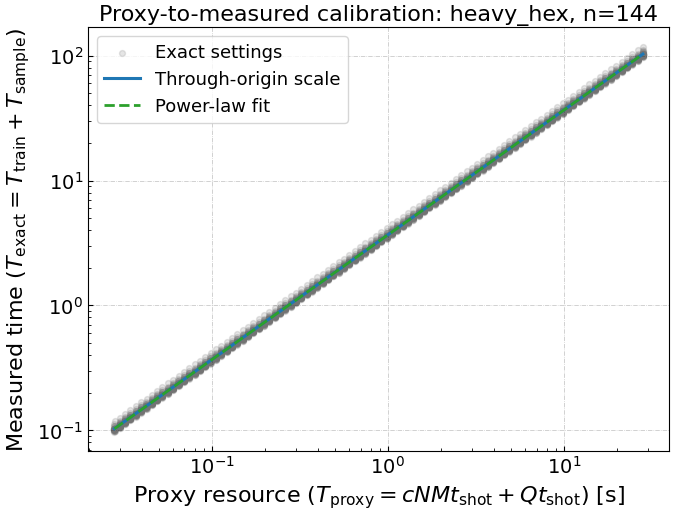

Recommended global scale to map proxy onto measured-time units:
  T_exact ≈ 3.67326 · T_proxy


""


Skipping exact-resource model plot: no prediction data found.


In [280]:
# Proxy vs measured-time calibration
calibration_df = exact_df.loc[:, [
    'instance', 'split', 'N', 'M', 'Q',
    'T_exact_proxy', 'T_exact', 'training_cost', 'sampling_cost'
]].copy()
calibration_df = calibration_df.dropna(subset=['T_exact_proxy', 'T_exact'])
calibration_df = calibration_df[
    (pd.to_numeric(calibration_df['T_exact_proxy'], errors='coerce') > 0)
    & (pd.to_numeric(calibration_df['T_exact'], errors='coerce') > 0)
].copy()

proxy_values = calibration_df['T_exact_proxy'].to_numpy(dtype=float)
exact_values = calibration_df['T_exact'].to_numpy(dtype=float)

alpha_origin = float(np.dot(proxy_values, exact_values) / np.dot(proxy_values, proxy_values))
alpha_affine, beta_affine = np.polyfit(proxy_values, exact_values, deg=1)
log_slope, log_intercept = np.polyfit(np.log(proxy_values), np.log(exact_values), deg=1)
log_prefactor = float(np.exp(log_intercept))

proxy_grid = np.geomspace(proxy_values.min(), proxy_values.max(), 200)
origin_line = alpha_origin * proxy_grid
affine_line = alpha_affine * proxy_grid + beta_affine
power_line = log_prefactor * proxy_grid**log_slope

calibration_summary_df = pd.DataFrame([
    {
        'model': 'through_origin',
        'expression': f'T_exact ≈ {alpha_origin:.6g} · T_proxy',
        'alpha': alpha_origin,
        'beta': 0.0,
        'power_slope': 1.0,
    },
    {
        'model': 'affine',
        'expression': f'T_exact ≈ {alpha_affine:.6g} · T_proxy + {beta_affine:.6g}',
        'alpha': float(alpha_affine),
        'beta': float(beta_affine),
        'power_slope': 1.0,
    },
    {
        'model': 'power_law',
        'expression': f'T_exact ≈ {log_prefactor:.6g} · T_proxy^{log_slope:.6g}',
        'alpha': log_prefactor,
        'beta': 0.0,
        'power_slope': float(log_slope),
    },
])
calibration_summary_df.to_csv(OUTPUT_ROOT / 'proxy_exact_calibration_summary.csv', index=False)

display(calibration_summary_df)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(calibration_df['T_exact_proxy'], calibration_df['T_exact'], s=18, alpha=0.18, color='0.45', label='Exact settings')
plt.plot(proxy_grid, origin_line, color='tab:blue', linewidth=2.2, label='Through-origin scale')
plt.plot(proxy_grid, power_line, color='tab:green', linewidth=2.0, linestyle='--', label='Power-law fit')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Proxy resource $(T_{\mathrm{proxy}} = c N M t_{\mathrm{shot}} + Q t_{\mathrm{shot}})$ [s]')
plt.ylabel(r'Measured time $(T_{\mathrm{exact}} = T_{\mathrm{train}} + T_{\mathrm{sample}})$')
plt.title(f'Proxy-to-measured calibration: {GRAPH_TYPE}, n={NUM_NODES}')
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('proxy_vs_exact_calibration', PLOT_DIR)
plt.show()

print('Recommended global scale to map proxy onto measured-time units:')
print(f'  T_exact ≈ {alpha_origin:.6g} · T_proxy')

# Exact-resource model selection: predict measured time directly from N, M, and Q.
exact_resource_model_summary_df, exact_resource_model_prediction_df = fit_exact_resource_models(
    exact_df,
    target_col='T_exact',
)
exact_resource_model_summary_df.to_csv(OUTPUT_ROOT / 'exact_resource_model_summary.csv', index=False)
exact_resource_model_prediction_df.to_csv(OUTPUT_ROOT / 'exact_resource_model_predictions.csv', index=False)

display(exact_resource_model_summary_df)
plot_exact_resource_model_predictions(
    exact_resource_model_prediction_df,
    exact_resource_model_summary_df,
    plot_dir=PLOT_DIR,
    filename='exact_resource_model_predictions',
)

if not exact_resource_model_summary_df.empty:
    print('Best measured-time resource model:')
    print('  ' + exact_resource_model_summary_df.iloc[0]['expression'])


In [281]:
# Run stochastic-benchmark on the clean proxy resource axis
WS_RESOURCE_AXIS = 'T_proxy'
WS_RESOURCE_FORMULA = 'T_proxy = t_preprocessing + N M t_shot + Q t_shot'
WS_FRONTIER_DF = frontier_df.copy()
WS_FRONTIER_NAME = 'frontier_df'
WS_XLABEL = r'Resource $(T_{\mathrm{proxy}} = t_{\mathrm{preprocessing}} + NMt_{\mathrm{shot}} + Qt_{\mathrm{shot}})$ [s]'
WS_TITLE = f'Window sticker on clean proxy resource: {GRAPH_TYPE}, n={NUM_NODES}'
WS_PLOT_SUFFIX = 'clean_proxy_resource'

ws_results = run_stochastic_benchmark_pss(
    WS_FRONTIER_DF,
    output_dir=WINDOW_STICKER_DIR,
    codebooks=ws_codebooks,
    response_col='BestApproximationRatio',
    resource_col='T',
    response_key='Response',
    bootstrap_range=BS_BOOTSTRAP_RANGE,
    train_test_split=TRAIN_TEST_SPLIT_FRACTION,
    clear_checkpoints=True,
)

virtual_best_df = ws_results['virtual_best_df']
projection_summary_df = ws_results['projection_summary_df']
window_sticker_summary_df = ws_results['window_sticker_summary_df']

resource_axis_summary_df = pd.DataFrame([
    {
        'axis': WS_RESOURCE_AXIS,
        'formula': WS_RESOURCE_FORMULA,
        'frontier': WS_FRONTIER_NAME,
        'rows': len(WS_FRONTIER_DF),
        'budget_points': WS_FRONTIER_DF['T'].nunique(),
        'resource_min': WS_FRONTIER_DF['T'].min(),
        'resource_max': WS_FRONTIER_DF['T'].max(),
    },
])

print('Clean-proxy raw exp_raw files written:', len(ws_results['written_files']))
display(virtual_best_df)
display(window_sticker_summary_df)
display(resource_axis_summary_df)


  0%|          | 0/100 [00:00<?, ?it/s]/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:121: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:121: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:121: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:121: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:121: UserWarning: Dataframe has duplicate resources. Dropping duplicates, b

Clean-proxy raw exp_raw files written: 30


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.029027,0.0,0.0,0.0,0.0,102.8,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
1,0.033327,0.0,0.0,0.0,0.0,115.8,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
2,0.033327,0.0,0.0,0.0,0.0,115.8,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
3,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.833668,0.020700,4,0.813382,0.853954,FA_PP_no_opt,MPSAer
4,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.833668,0.020700,4,0.813382,0.853954,FA_PP_no_opt,MPSAer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,22.011284,0.0,0.0,0.0,0.0,81113.0,5.0,0.879954,0.020375,10,0.867325,0.892583,FA_PP_no_opt,MPSAer
163,23.585429,0.0,0.0,0.0,0.0,86975.0,5.0,0.880403,0.020519,10,0.867685,0.893121,FA_PP_no_opt,MPSAer
164,23.585429,0.0,0.0,0.0,0.0,86975.0,5.0,0.880403,0.020519,10,0.867685,0.893121,FA_PP_no_opt,MPSAer
165,25.272149,0.0,0.0,0.0,0.0,93260.0,5.0,0.880403,0.020519,10,0.867685,0.893121,FA_PP_no_opt,MPSAer


,resource,strategy,simulation_method,N,M,Q,p,response,response_lower,response_upper
0,0.029027,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,5.0,0.826365,0.812946,0.839784
1,0.033327,FA_PP_no_opt,MPSAer,0.0,0.0,115.0,5.0,0.826365,0.812946,0.839784
2,0.033327,FA_PP_no_opt,MPSAer,0.0,0.0,115.0,5.0,0.826365,0.812946,0.839784
3,0.035710,FA_PP_no_opt,MPSAer,0.0,0.0,123.0,5.0,0.833668,0.813382,0.853954
4,0.035710,FA_PP_no_opt,MPSAer,0.0,0.0,123.0,5.0,0.833668,0.813382,0.853954
...,...,...,...,...,...,...,...,...,...,...
162,22.011284,FA_PP_no_opt,MPSAer,0.0,0.0,81113.0,5.0,0.879954,0.867325,0.892583
163,23.585429,FA_PP_no_opt,MPSAer,0.0,0.0,86975.0,5.0,0.880403,0.867685,0.893121
164,23.585429,FA_PP_no_opt,MPSAer,0.0,0.0,86975.0,5.0,0.880403,0.867685,0.893121
165,25.272149,FA_PP_no_opt,MPSAer,0.0,0.0,93260.0,5.0,0.880403,0.867685,0.893121


,axis,formula,frontier,rows,budget_points,resource_min,resource_max
0,T_proxy,T_proxy = t_preprocessing + N M t_shot + Q t_shot,frontier_df,3000,100,0.029027,27.079495


## Window Sticker on Clean Proxy Resource (`T_proxy`)

All Window Sticker results below use `T_proxy = t_preprocessing + N M t_shot + Q t_shot` as the resource coordinate. This treats MPSAer as the data generator and ranks prescriptions by the hardware-shot-style budget, while charging any explicit preprocessing cost such as parameter-transfer lookup.


,strategy,simulation_method,p,T,response_mean,response_std,response_min,response_max,N_mean,M_mean,Q_mean,training_cost_mean,sampling_cost_mean,training_cost_proxy_mean,sampling_cost_proxy_mean,T_exact_mean,T_exact_proxy_mean,n_instances,n_candidates
0,FA_PP_no_opt,MPSAer,5,0.029027,0.837263,0.027762,0.785124,0.881109,0.0,0.0,103.410256,0.000027,0.106297,0.000027,0.028987,0.106324,0.029014,20,39
1,FA_PP_no_opt,MPSAer,5,0.031103,0.848876,0.000000,0.848876,0.848876,0.0,0.0,107.000000,0.000114,0.106144,0.000114,0.029993,0.106259,0.030108,1,1
2,FA_PP_no_opt,MPSAer,5,0.033327,0.838371,0.027021,0.785124,0.881109,0.0,0.0,117.074074,0.000026,0.120179,0.000026,0.032817,0.120205,0.032843,20,27
3,FA_PP_no_opt,MPSAer,5,0.035710,0.838347,0.030235,0.785124,0.881109,0.0,0.0,123.000000,0.000037,0.126432,0.000037,0.034478,0.126469,0.034515,13,13
4,FA_PP_no_opt,MPSAer,5,0.038264,0.838879,0.028222,0.785124,0.881109,0.0,0.0,132.000000,0.000029,0.135562,0.000029,0.037001,0.135591,0.037030,20,20
5,FA_PP_no_opt,MPSAer,5,0.041001,0.838879,0.028222,0.785124,0.881109,0.0,0.0,142.000000,0.000029,0.145832,0.000029,0.039804,0.145861,0.039833,20,20
6,FA_PP_no_opt,MPSAer,5,0.043933,0.838903,0.028229,0.785124,0.881109,0.0,0.0,152.000000,0.000029,0.156102,0.000029,0.042607,0.156131,0.042636,20,20
7,FA_PP_no_opt,MPSAer,5,0.047075,0.841028,0.028228,0.785124,0.881109,0.0,0.0,163.000000,0.000029,0.167399,0.000029,0.045690,0.167428,0.045720,20,20
8,FA_PP_no_opt,MPSAer,5,0.050441,0.841578,0.028502,0.785124,0.881109,0.0,0.0,175.000000,0.000029,0.179723,0.000029,0.049054,0.179752,0.049084,20,20
9,FA_PP_no_opt,MPSAer,5,0.054049,0.841762,0.028495,0.785124,0.881109,0.0,0.0,187.000000,0.000029,0.192046,0.000029,0.052418,0.192076,0.052447,20,20


,resource,strategy_code,simulation_code,N,M,Q,p,response,n_instances,n_virtual_best_rows,strategy,simulation_method
0,0.029027,0.0,0.0,0.0,0.0,102.45,5.0,0.837885,20,20,FA_PP_no_opt,MPSAer
1,0.031103,0.0,0.0,0.0,0.0,107.00,5.0,0.848876,1,1,FA_PP_no_opt,MPSAer
2,0.031103,0.0,0.0,0.0,0.0,107.00,5.0,0.848876,1,1,FA_PP_no_opt,MPSAer
3,0.033327,0.0,0.0,0.0,0.0,115.80,5.0,0.838513,20,20,FA_PP_no_opt,MPSAer
4,0.033327,0.0,0.0,0.0,0.0,115.40,5.0,0.838513,20,20,FA_PP_no_opt,MPSAer
5,0.035710,0.0,0.0,0.0,0.0,123.00,5.0,0.838347,13,13,FA_PP_no_opt,MPSAer
6,0.035710,0.0,0.0,0.0,0.0,123.00,5.0,0.838347,13,13,FA_PP_no_opt,MPSAer
7,0.038264,0.0,0.0,0.0,0.0,132.00,5.0,0.838879,20,20,FA_PP_no_opt,MPSAer
8,0.038264,0.0,0.0,0.0,0.0,132.00,5.0,0.838879,20,20,FA_PP_no_opt,MPSAer
9,0.041001,0.0,0.0,0.0,0.0,142.00,5.0,0.838879,20,20,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.029027,0.0,0.0,0.0,0.0,102.45,5.0,10.0,FA_PP_no_opt,MPSAer
1,0.031103,0.0,0.0,0.0,0.0,107.00,5.0,10.0,FA_PP_no_opt,MPSAer
2,0.031103,0.0,0.0,0.0,0.0,107.00,5.0,20.0,FA_PP_no_opt,MPSAer
3,0.033327,0.0,0.0,0.0,0.0,115.80,5.0,10.0,FA_PP_no_opt,MPSAer
4,0.033327,0.0,0.0,0.0,0.0,115.40,5.0,20.0,FA_PP_no_opt,MPSAer
5,0.035710,0.0,0.0,0.0,0.0,123.00,5.0,10.0,FA_PP_no_opt,MPSAer
6,0.035710,0.0,0.0,0.0,0.0,123.00,5.0,40.0,FA_PP_no_opt,MPSAer
7,0.038264,0.0,0.0,0.0,0.0,132.00,5.0,10.0,FA_PP_no_opt,MPSAer
8,0.038264,0.0,0.0,0.0,0.0,132.00,5.0,20.0,FA_PP_no_opt,MPSAer
9,0.041001,0.0,0.0,0.0,0.0,142.00,5.0,10.0,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.029027,0.0,0.0,NaN,NaN,102.450000,5.0,10.0,FA_PP_no_opt,MPSAer
1,0.031103,0.0,0.0,NaN,NaN,107.364140,5.0,10.0,FA_PP_no_opt,MPSAer
2,0.031103,0.0,0.0,NaN,NaN,107.364140,5.0,20.0,FA_PP_no_opt,MPSAer
3,0.033327,0.0,0.0,NaN,NaN,115.116982,5.0,10.0,FA_PP_no_opt,MPSAer
4,0.033327,0.0,0.0,NaN,NaN,115.116982,5.0,20.0,FA_PP_no_opt,MPSAer
5,0.035710,0.0,0.0,NaN,NaN,123.429776,5.0,10.0,FA_PP_no_opt,MPSAer
6,0.035710,0.0,0.0,NaN,NaN,123.429776,5.0,40.0,FA_PP_no_opt,MPSAer
7,0.038264,0.0,0.0,NaN,NaN,132.342973,5.0,10.0,FA_PP_no_opt,MPSAer
8,0.038264,0.0,0.0,NaN,NaN,132.342973,5.0,20.0,FA_PP_no_opt,MPSAer
9,0.041001,0.0,0.0,NaN,NaN,141.899947,5.0,10.0,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.029027,0.0,0.0,0.0,0.0,100.0,5.0,0.837220,0.027798,20,0.825037,0.849403,FA_PP_no_opt,MPSAer
1,0.031103,0.0,0.0,0.0,0.0,107.0,5.0,0.848876,NaN,1,0.848876,0.848876,FA_PP_no_opt,MPSAer
2,0.031103,0.0,0.0,0.0,0.0,107.0,5.0,0.848876,NaN,1,0.848876,0.848876,FA_PP_no_opt,MPSAer
3,0.033327,0.0,0.0,0.0,0.0,115.0,5.0,0.837885,0.027847,20,0.825681,0.850090,FA_PP_no_opt,MPSAer
4,0.033327,0.0,0.0,0.0,0.0,115.0,5.0,0.837885,0.027847,20,0.825681,0.850090,FA_PP_no_opt,MPSAer
5,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.838347,0.030235,13,0.821911,0.854783,FA_PP_no_opt,MPSAer
6,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.838347,0.030235,13,0.821911,0.854783,FA_PP_no_opt,MPSAer
7,0.038264,0.0,0.0,0.0,0.0,132.0,5.0,0.838879,0.028222,20,0.826510,0.851248,FA_PP_no_opt,MPSAer
8,0.038264,0.0,0.0,0.0,0.0,132.0,5.0,0.838879,0.028222,20,0.826510,0.851248,FA_PP_no_opt,MPSAer
9,0.041001,0.0,0.0,0.0,0.0,142.0,5.0,0.838879,0.028222,20,0.826510,0.851248,FA_PP_no_opt,MPSAer


...

,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.029027,0.0,0.0,0.0,0.0,100.0,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
1,0.033327,0.0,0.0,0.0,0.0,115.0,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
2,0.033327,0.0,0.0,0.0,0.0,115.0,5.0,0.826365,0.021650,10,0.812946,0.839784,FA_PP_no_opt,MPSAer
3,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.833668,0.020700,4,0.813382,0.853954,FA_PP_no_opt,MPSAer
4,0.035710,0.0,0.0,0.0,0.0,123.0,5.0,0.833668,0.020700,4,0.813382,0.853954,FA_PP_no_opt,MPSAer
5,0.038264,0.0,0.0,0.0,0.0,132.0,5.0,0.826692,0.021322,10,0.813477,0.839907,FA_PP_no_opt,MPSAer
6,0.038264,0.0,0.0,0.0,0.0,132.0,5.0,0.826692,0.021322,10,0.813477,0.839907,FA_PP_no_opt,MPSAer
7,0.041001,0.0,0.0,0.0,0.0,142.0,5.0,0.826692,0.021322,10,0.813477,0.839907,FA_PP_no_opt,MPSAer
8,0.041001,0.0,0.0,0.0,0.0,142.0,5.0,0.826692,0.021322,10,0.813477,0.839907,FA_PP_no_opt,MPSAer
9,0.043933,0.0,0.0,0.0,0.0,152.0,5.0,0.826692,0.021322,10,0.813477,0.839907,FA_PP_no_opt,MPSAer


,parameter,expression,coeff_0,coeff_1,coeff_2
0,Q,Q(T) = exp(8.18 + 1.01 log(T) + 9.634e-05 log(...,8.18042,1.010054,0.000096


,graph type,num nodes,resource axis,fitted strategy,fitted p,fitted N,fitted M,fitted Q,fitted response
0,heavy_hex,144,T_proxy,FA_PP_no_opt,5.0,0.0,0.0,86975.0,0.880403


,dataset,n_rows,resource_min,resource_max
0,train frontier_df,2000,0.029027,27.079495
1,test frontier_df,1000,0.029027,27.079495
2,train virtual-best lookup,169,0.029027,27.079495
3,fitted prescription test,167,0.029027,27.079495


Actionable prescription equations on T_proxy:
  Q(T) = exp(8.18 + 1.01 log(T) + 9.634e-05 log(T)^2)
Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/cost_vs_best_approximation_ratio_clean_proxy_resource.pdf and .png


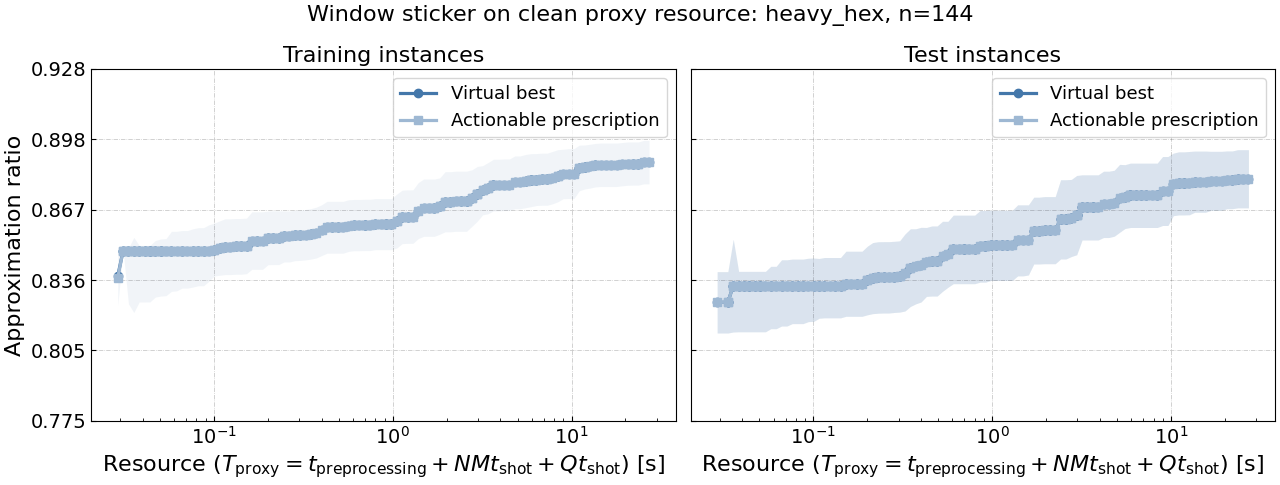

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/parameter_prescriptions_clean_proxy_resource.pdf and .png


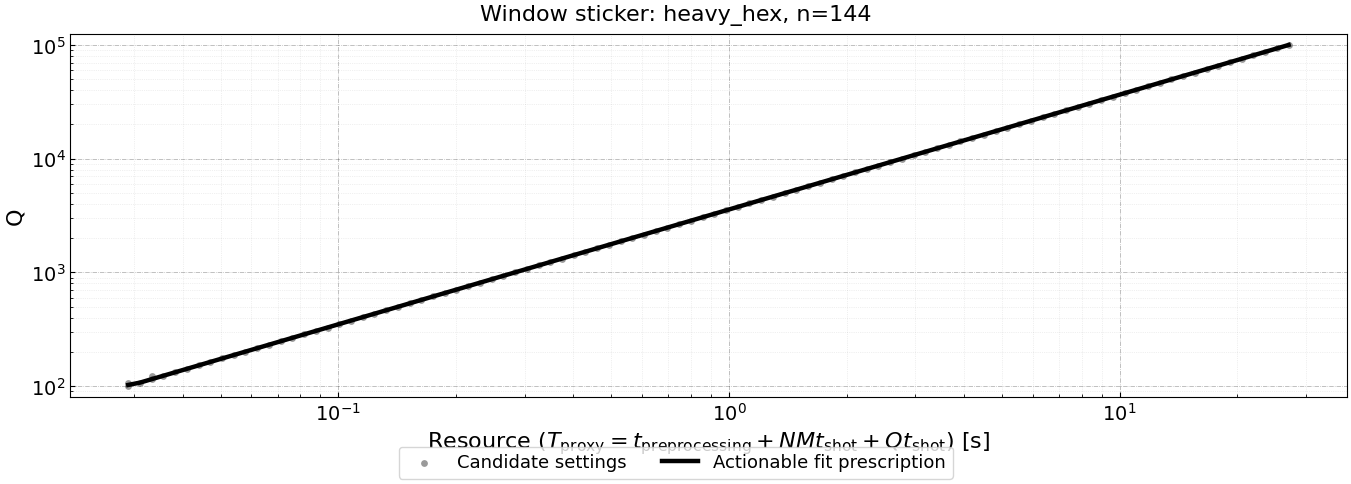

,strategy,T,ApproximationRatio
0,FA_PP_no_opt,0.029027,0.837263
1,FA_PP_no_opt,0.031103,0.848876
2,FA_PP_no_opt,0.033327,0.838371
3,FA_PP_no_opt,0.035710,0.838347
4,FA_PP_no_opt,0.038264,0.838879
...,...,...,...
95,FA_PP_no_opt,20.542202,0.887034
96,FA_PP_no_opt,22.011284,0.887067
97,FA_PP_no_opt,23.585429,0.887067
98,FA_PP_no_opt,25.272149,0.887687


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/per_method_cost_performance_clean_proxy_resource.pdf and .png


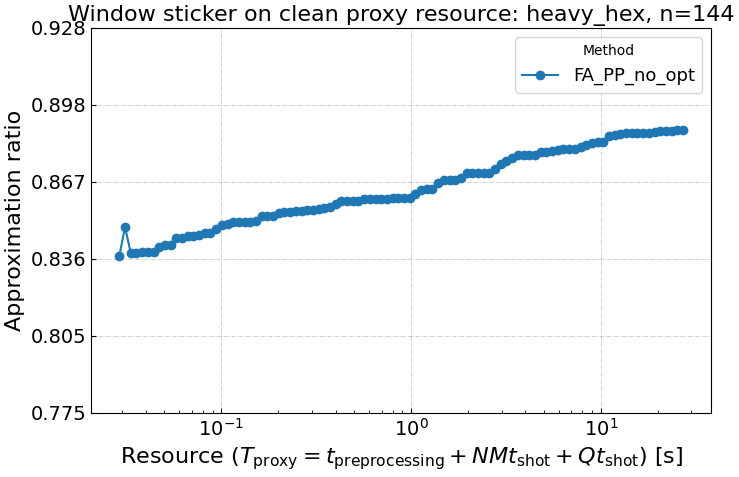

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/monotone_envelope_comparison_clean_proxy_resource.pdf and .png


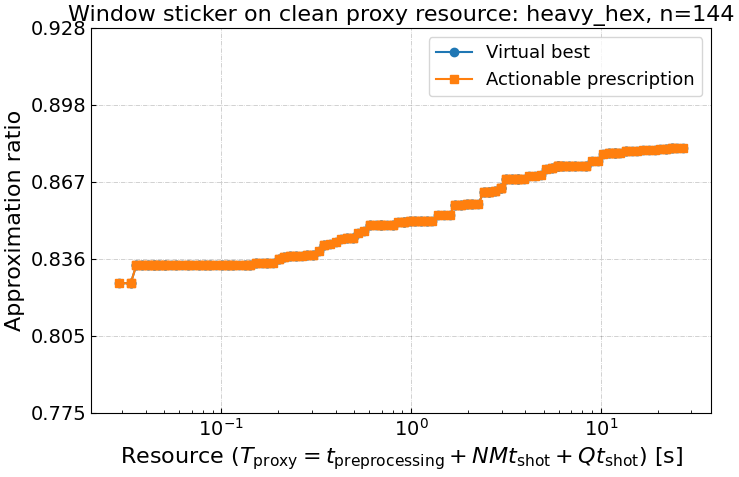

In [282]:
# Active-resource summaries and plots
strategy_budget_df = build_strategy_budget_summary(WS_FRONTIER_DF, split='train')
vb_train_lookup_df = ws_results['vb_train_lookup_df'].copy()
lookup_recipe_train_df = ws_results['recipe_train_df'].copy()
lookup_train_eval_df = ws_results['actionable_train_eval_df'].copy()
fitted_recipe_train_df = ws_results['fitted_recipe_df'].copy()
fitted_train_eval_df = ws_results['fitted_train_eval_df'].copy()
fitted_test_eval_df = ws_results['fitted_test_eval_df'].copy()
fitted_recipe_model_df = ws_results['fitted_recipe_model_df'].copy()
lookup_test_eval_df = window_sticker_summary_df.copy()

best_fitted_df = fitted_test_eval_df.sort_values(['response', 'resource'], ascending=[False, True]).reset_index(drop=True)
recommendation_summary = pd.DataFrame([
    {
        'graph type': GRAPH_TYPE,
        'num nodes': NUM_NODES,
        'resource axis': WS_RESOURCE_AXIS,
        'fitted strategy': best_fitted_df.iloc[0]['strategy'] if not best_fitted_df.empty else None,
        'fitted p': best_fitted_df.iloc[0]['p'] if not best_fitted_df.empty else None,
        'fitted N': best_fitted_df.iloc[0]['N'] if not best_fitted_df.empty else None,
        'fitted M': best_fitted_df.iloc[0]['M'] if not best_fitted_df.empty else None,
        'fitted Q': best_fitted_df.iloc[0]['Q'] if not best_fitted_df.empty else None,
        'fitted response': best_fitted_df.iloc[0]['response'] if not best_fitted_df.empty else None,
    }
])

display(strategy_budget_df.head(20))
display(vb_train_lookup_df.head(20))
display(lookup_recipe_train_df.head(20))
display(fitted_recipe_train_df.head(20))
display(lookup_train_eval_df.head(20))
display(fitted_train_eval_df.head(20))
display(fitted_test_eval_df.head(20))
display(fitted_recipe_model_df)
display(recommendation_summary)

resource_support_debug_df = pd.DataFrame([
    {
        'dataset': f'train {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('train')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].max(),
    },
    {
        'dataset': f'test {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('test')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].max(),
    },
    {
        'dataset': 'train virtual-best lookup',
        'n_rows': len(vb_train_lookup_df),
        'resource_min': vb_train_lookup_df['resource'].min() if not vb_train_lookup_df.empty else None,
        'resource_max': vb_train_lookup_df['resource'].max() if not vb_train_lookup_df.empty else None,
    },
    {
        'dataset': 'fitted prescription test',
        'n_rows': len(fitted_test_eval_df),
        'resource_min': fitted_test_eval_df['resource'].min() if not fitted_test_eval_df.empty else None,
        'resource_max': fitted_test_eval_df['resource'].max() if not fitted_test_eval_df.empty else None,
    },
])
display(resource_support_debug_df)

if not fitted_recipe_model_df.empty:
    print(f'Actionable prescription equations on {WS_RESOURCE_AXIS}:')
    for expression in fitted_recipe_model_df['expression'].dropna().tolist():
        print('  ' + expression)

shared_approx_ylim = compute_shared_approx_ylim(
    virtual_best_df.get('response'),
    fitted_test_eval_df.get('response'),
    lookup_test_eval_df.get('response'),
    vb_train_lookup_df.get('response'),
    lookup_train_eval_df.get('response'),
    fitted_train_eval_df.get('response'),
    strategy_budget_df.get('response_mean'),
    WS_FRONTIER_DF.get('BestApproximationRatio'),
)
shared_approx_yticks = compute_shared_approx_yticks(shared_approx_ylim)

train_virtual_best_monotone_df = prepare_monotone_curve(vb_train_lookup_df)
lookup_train_monotone_df = prepare_monotone_curve(lookup_train_eval_df)
fitted_train_monotone_df = prepare_monotone_curve(fitted_train_eval_df)
test_virtual_best_monotone_df = prepare_monotone_curve(virtual_best_df)
lookup_test_monotone_df = prepare_monotone_curve(lookup_test_eval_df)
fitted_test_monotone_df = prepare_monotone_curve(fitted_test_eval_df)

xlabel = WS_XLABEL
exact_ylabel = 'Approximation ratio'
main_title = WS_TITLE
single_method_label = curve_label(strategy_budget_df, RESULT_TAG)
single_method_colors = window_sticker_curve_colors(single_method_label)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_specs = [
    (axes[0], train_virtual_best_monotone_df, fitted_train_monotone_df, lookup_train_monotone_df, 'Training instances'),
    (axes[1], test_virtual_best_monotone_df, fitted_test_monotone_df, lookup_test_monotone_df, 'Test instances'),
]
for ax, vb_curve, fitted_curve, lookup_curve, title in plot_specs:
    for curve, color_key, label, marker, linewidth, alpha in [
        (vb_curve, 'virtual_best', 'Virtual best', 'o', 2.3, 1.0),
        (fitted_curve, 'actionable_prescription', 'Actionable prescription', 's', 2.3, 1.0),
    ]:
        if curve.empty:
            continue
        color = single_method_colors[color_key]
        lower_col = 'response_lower_monotone' if 'response_lower_monotone' in curve.columns else 'response_lower'
        upper_col = 'response_upper_monotone' if 'response_upper_monotone' in curve.columns else 'response_upper'
        if lower_col in curve.columns and upper_col in curve.columns:
            band = curve.dropna(subset=['resource', lower_col, upper_col])
            if not band.empty:
                ax.fill_between(
                    band['resource'].to_numpy(dtype=float),
                    band[lower_col].to_numpy(dtype=float),
                    band[upper_col].to_numpy(dtype=float),
                    color=color,
                    alpha=0.14,
                    linewidth=0,
                    zorder=1,
                )
        if linewidth > 0:
            ax.plot(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                linewidth=linewidth,
                label=label,
                zorder=3,
            )
        else:
            ax.scatter(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                s=34,
                alpha=alpha,
                label=label,
                zorder=3,
            )
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    apply_shared_approx_axis(ax, ylim=shared_approx_ylim, yticks=shared_approx_yticks)
    ax.legend()
axes[0].set_ylabel(exact_ylabel)
fig.suptitle(main_title)
fig.tight_layout()
save_current_plot(f'cost_vs_best_approximation_ratio_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

active_candidate_parameter_df = WS_FRONTIER_DF[
    WS_FRONTIER_DF['split'].astype(str).eq('train')
].drop_duplicates(['instance', 'N', 'M', 'Q', 'T']).copy()

plot_parameter_prescriptions_by_resource(
    candidate_df=active_candidate_parameter_df,
    virtual_best_df=vb_train_lookup_df,
    lookup_df=lookup_train_eval_df,
    actionable_df=fitted_recipe_train_df,
    candidate_resource_col='T',
    curve_resource_col='resource',
    plot_dir=PLOT_DIR,
    filename=f'parameter_prescriptions_{WS_PLOT_SUFFIX}',
    title=f'Window sticker: {GRAPH_TYPE}, n={NUM_NODES}',
    xlabel=xlabel,
    connect_points=True,
    connect_lookup=False,
    show_virtual_best=False,
    show_lookup=False,
    actionable_marker=None,
)

per_method_curve_df = strategy_budget_df.loc[:, ['strategy', 'T', 'response_mean']].rename(columns={'response_mean': 'ApproximationRatio'})
display(per_method_curve_df)
plt.figure(figsize=(8, 5))
for strategy_name, group in per_method_curve_df.groupby('strategy'):
    plt.plot(group['T'], group['ApproximationRatio'], marker='o', label=strategy_name)
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend(title='Method')
save_current_plot(f'per_method_cost_performance_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(test_virtual_best_monotone_df['resource'], test_virtual_best_monotone_df['response_monotone'], marker='o', label='Virtual best')
plt.plot(fitted_test_monotone_df['resource'], fitted_test_monotone_df['response_monotone'], marker='s', label='Actionable prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot(f'monotone_envelope_comparison_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

## Multi-Strategy Window Sticker Comparison

This section compares completed strategy roots listed in `COMPARISON_RESULT_TAGS`. Each result root must first have its single-strategy Window Sticker summary generated (`window_sticker_summary.csv`). Training summaries are loaded when present and rebuilt from `pss_exp_raw_frontier.pkl` when needed.


Loaded strategy roots:
  Fixed Angles$^\star$ (p=5): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
  Linear Ramp (p=5): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_LR_opt_p5_expanded
  Param. Transfer (p=7): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p7_expanded
  Param. Transfer (p=6): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p6_expanded
  Param. Transfer (p=5): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p5_expanded
  Param. Transfer (p=3): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p3_expanded
  Param. Transfer (p=2): /mnt/c/Users/rames102/Desktop/stochastic

,method_label,strategy,simulation_method,p,T,response_mean,N_mean,M_mean,Q_mean,T_exact_proxy_mean,n_instances,n_candidates
0,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000500,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
1,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000503,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
2,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000507,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
3,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000510,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
4,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000514,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
5,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000517,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
6,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000520,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
7,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000524,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
8,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000527,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
9,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000531,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p5_expanded/notebook_plots/multi_method_window_sticker_component_panels.pdf and .png


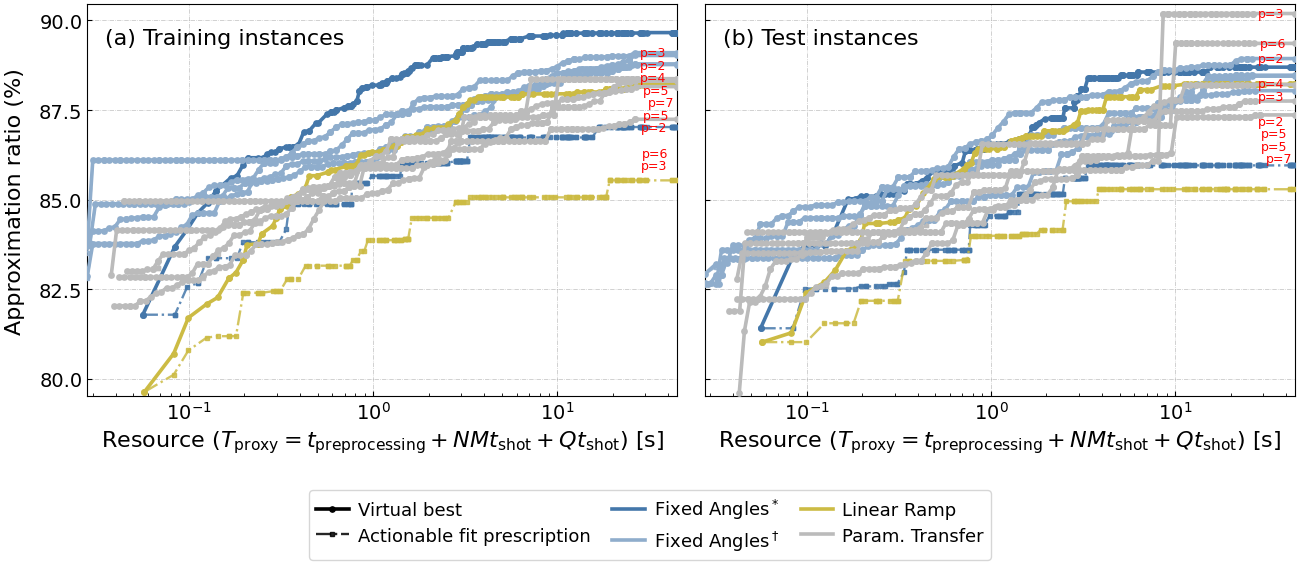

In [289]:
# Multi-strategy actionable PSS comparison
# Add future strategy result tags here after those campaigns finish.
MULTI_STRATEGY_RESULT_TAGS = list(COMPARISON_RESULT_TAGS)

PSS_RESULTS_BASE = OUTPUT_ROOT.parent

required_summary_files = ['window_sticker_summary.csv']
missing_summary_files = []
for tag in MULTI_STRATEGY_RESULT_TAGS:
    root = PSS_RESULTS_BASE / tag
    for filename in required_summary_files:
        if not (root / filename).exists():
            missing_summary_files.append(root / filename)
if missing_summary_files:
    print('Missing Window Sticker summary files for multi-strategy comparison:')
    for path in missing_summary_files:
        print(f'  {path}')
    if SKIP_MISSING_MULTI_STRATEGY_SUMMARIES:
        missing_tags = {path.parent.name for path in missing_summary_files}
        MULTI_STRATEGY_RESULT_TAGS = [
            tag for tag in MULTI_STRATEGY_RESULT_TAGS if tag not in missing_tags
        ]
        print('Skipping unfinished strategy roots:', sorted(missing_tags))
    else:
        raise FileNotFoundError(
            'Generate the missing single-strategy Window Sticker summary first. '
            'For a new strategy, rerun its load + Window Sticker cells once.'
        )

multi_strategy_summaries = load_multi_strategy_summaries(MULTI_STRATEGY_RESULT_TAGS, PSS_RESULTS_BASE)
print('Loaded strategy roots:')
for item in multi_strategy_summaries:
    print(f"  {item['method_label']}: {item['root']}")

multi_strategy_budget_df = concat_summary(multi_strategy_summaries, 'strategy_budget')
multi_actionable_lookup_df = concat_summary(multi_strategy_summaries, 'actionable_lookup')
multi_actionable_fit_df = concat_summary(multi_strategy_summaries, 'actionable_fit')
multi_window_sticker_df = concat_summary(multi_strategy_summaries, 'window_sticker')
multi_virtual_best_df = concat_summary(multi_strategy_summaries, 'virtual_best')
multi_virtual_best_train_df = concat_summary(multi_strategy_summaries, 'virtual_best_train')
multi_fitted_projection_train_df = concat_summary(multi_strategy_summaries, 'fitted_projection_train')
multi_fitted_projection_test_df = concat_summary(multi_strategy_summaries, 'fitted_projection_test')

training_strategy_curve_df = curve_from_training_summary(multi_strategy_budget_df)
training_virtual_best_component_cols = [
    col for col in [
        'method_label', 'T', 'response_monotone',
        'response_lower_monotone', 'response_upper_monotone',
    ]
    if col in training_strategy_curve_df.columns
]
training_virtual_best_components_df = training_strategy_curve_df.loc[
    :, training_virtual_best_component_cols
].rename(
    columns={
        'T': 'resource',
        'response_monotone': 'response',
        'response_lower_monotone': 'response_lower',
        'response_upper_monotone': 'response_upper',
    }
)
training_strategy_envelope_df = cross_strategy_envelope(training_strategy_curve_df, 'T')

actionable_projection_curve_df = curve_from_window_summary(multi_window_sticker_df)
actionable_projection_envelope_df = cross_strategy_envelope(actionable_projection_curve_df, 'resource')

# This table is the direct answer to: which hyperparameters define the strategy curve at each budget?
hyperparameter_lookup_cols = [
    col for col in [
        'method_label', 'strategy', 'simulation_method', 'p', 'T', 'response_mean',
        'N_mean', 'M_mean', 'Q_mean', 'T_exact_proxy_mean', 'n_instances', 'n_candidates',
    ]
    if col in multi_actionable_lookup_df.columns
]
hyperparameter_lookup_df = multi_actionable_lookup_df.loc[:, hyperparameter_lookup_cols].copy() if hyperparameter_lookup_cols else pd.DataFrame()

if not hyperparameter_lookup_df.empty:
    hyperparameter_lookup_df.to_csv(OUTPUT_ROOT / 'multi_strategy_hyperparameter_lookup.csv', index=False)
if not training_strategy_envelope_df.empty:
    training_strategy_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_training_envelope.csv', index=False)
if not actionable_projection_envelope_df.empty:
    actionable_projection_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_actionable_projection_envelope.csv', index=False)

print('Hyperparameter lookup rows:', len(hyperparameter_lookup_df))
display(hyperparameter_lookup_df.head(20))

# Refresh plotting helper to avoid stale notebook/autoreload function objects.
import importlib
from src import utils as ibm_qaoa_plot_utils
ibm_qaoa_plot_utils = importlib.reload(ibm_qaoa_plot_utils)
plot_multi_method_window_sticker_component_panels = ibm_qaoa_plot_utils.plot_multi_method_window_sticker_component_panels

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=multi_virtual_best_train_df,
    training_fitted_prescription_df=multi_fitted_projection_train_df,
    test_virtual_best_df=multi_virtual_best_df,
    test_fitted_prescription_df=multi_fitted_projection_test_df,
    filename='multi_method_window_sticker_component_panels',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
)
